In [1]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns 

# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# # data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
list1 = df_US['job_title_short'].value_counts().index.tolist()[0:3]
list1 = sorted(list1)
df_US = df[(df['job_country']  == 'United States') & (df['job_title_short'].isin(list1))].copy()
df_job_count = df_US['job_title_short'].value_counts().reset_index(name='job_count')

In [78]:
df_US = df_US.explode('job_skills')
df_US_G = df_US.groupby(['job_title_short','job_skills']).size().reset_index(name='skill_count').sort_values(by='skill_count',ascending=False)
df_merged = df_US_G.merge(df_job_count, on= 'job_title_short', how= 'inner')
df_merged['Percentage'] = df_merged['skill_count']/df_merged['job_count']*100
df_merged

,job_title_short,job_skills,skill_count,job_count,Percentage
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
662,Data Analyst,kotlin,1,67816,0.001475
663,Data Scientist,shogun,1,58830,0.001700
664,Data Analyst,ionic,1,67816,0.001475
665,Data Analyst,capacitor,1,67816,0.001475


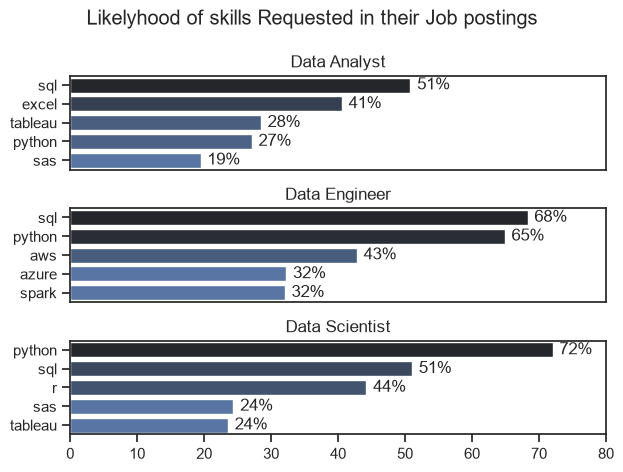

In [79]:
fig,ax = plt.subplots(3,1)
sns.set_theme(style='ticks')


for i, title in enumerate(list1):
    df_plot = df_merged[df_merged['job_title_short'] == title].head()
    sns.barplot(data=df_plot, y='job_skills', x='Percentage', ax=ax[i], hue='Percentage', palette = 'dark:b_r', legend=False)
    ax[i].set_title(title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,80)

    for n, v in enumerate(df_plot['Percentage']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va = 'center')


    if i != len(list1)-1:
        ax[i].set_xticks([])

plt.suptitle('Likelyhood of skills Requested in their Job postings')
fig.tight_layout()


,job_title_short,job_skills,skill_count,job_count,Percentage
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
662,Data Analyst,kotlin,1,67816,0.001475
663,Data Scientist,shogun,1,58830,0.001700
664,Data Analyst,ionic,1,67816,0.001475
665,Data Analyst,capacitor,1,67816,0.001475
